In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit 

import glob, sys, os, math, gc, sklearn, scipy 

print(f'Tensorflow V{tf.__version__}')
print(f'Keras V{tf.keras.__version__}')
print(f'Python V{sys.version}') 

2026-02-23 07:32:49.926811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771831970.137643      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771831970.206475      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771831970.744871      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771831970.744908      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771831970.744911      55 computation_placer.cc:177] computation placer alr

Tensorflow V2.19.0
Keras V3.10.0
Python V3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# MatplotLib Global Settings
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 24 

In [3]:
# Set to True because the preprocessing logic was changed (added motion features) 
PREPROCESS_DATA = True 
TRAIN_MODEL = True
USE_VAL = True  # Keep True for tuning, set False for final Kaggle submission

# Mixed Precision on P100 acts as a turbo boost: 2x faster training, 50% less VRAM usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Data Dimensions
N_ROWS = 543
N_DIMS = 3
DIM_NAMES = ['x', 'y', 'z']
SEED = 42
NUM_CLASSES = 250
IS_INTERACTIVE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') == 'Interactive'
VERBOSE = 1 if IS_INTERACTIVE else 2

# INPUT CONFIGURATION
# Increased to 128 to capture fine temporal details (fingerspelling)
INPUT_SIZE = 128 

# Training Hyperparameters
BATCH_ALL_SIGNS_N = 4
BATCH_SIZE = 64
N_EPOCHS = 200 # 100
LR_MAX =  4e-4 #1e-3
N_WARMUP_EPOCHS = 10 # Slight warmup helps Transformer stability
WD_RATIO = 0.05
MASK_VAL = 0.0 

# Data type config
DATA_DTYPE = np.float16

print(f'Compute Policy: {policy.compute_dtype}')
print(f'Variable Policy: {policy.variable_dtype}')

Compute Policy: float16
Variable Policy: float32


In [4]:
# Prints Shape and Dtype For List Of Variables
def print_shape_dtype(l, names):
    for e, n in zip(l, names):
        print(f'{n} shape: {e.shape}, dtype: {e.dtype}') 

In [5]:
# Read Training Data
#if IS_INTERACTIVE or not PREPROCESS_DATA:
#train = pd.read_csv('/kaggle/input/asl-signs/train.csv').sample(int(5e3), random_state=SEED)
#else:
train = pd.read_csv('/kaggle/input/competitions/asl-signs/train.csv')

N_SAMPLES = len(train)
print(f'N_SAMPLES: {N_SAMPLES}') 

N_SAMPLES: 94477


In [6]:
# Get complete file path to file
def get_file_path(path):
    #return f'/kaggle/input/asl-signs/{path}'
    return f'/kaggle/input/competitions/asl-signs/{path}'
    

train['file_path'] = train['path'].apply(get_file_path) #

# Ordinally Encode Sign

In [7]:
# Add ordinally Encoded Sign (assign number to each sign name)
train['sign_ord'] = train['sign'].astype('category').cat.codes

# Dictionaries to translate sign to ordinal encoded sign
SIGN2ORD = train[['sign', 'sign_ord']].set_index('sign').squeeze().to_dict()
ORD2SIGN = train[['sign_ord', 'sign']].set_index('sign_ord').squeeze().to_dict() 

In [8]:
display(train.sample(n=5)) 
display(train.info()) 

,path,participant_id,sequence_id,sign,file_path,sign_ord
7280,train_landmark_files/53618/1303197369.parquet,53618,1303197369,cheek,/kaggle/input/competitions/asl-signs/train_lan...,41
23486,train_landmark_files/37055/1967825560.parquet,37055,1967825560,boy,/kaggle/input/competitions/asl-signs/train_lan...,29
84543,train_landmark_files/61333/592973569.parquet,61333,592973569,head,/kaggle/input/competitions/asl-signs/train_lan...,110
17676,train_landmark_files/49445/1729694608.parquet,49445,1729694608,owie,/kaggle/input/competitions/asl-signs/train_lan...,164
26382,train_landmark_files/26734/2089385065.parquet,26734,2089385065,high,/kaggle/input/competitions/asl-signs/train_lan...,117


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
 4   file_path       94477 non-null  object
 5   sign_ord        94477 non-null  int16 
dtypes: int16(1), int64(2), object(3)
memory usage: 3.8+ MB


None

# EDA

In [9]:
N = int(1e3) if (IS_INTERACTIVE or not PREPROCESS_DATA) else int(10e3)
N_UNIQUE_FRAMES = np.zeros(N, dtype=np.uint16)
N_MISSING_FRAMES = np.zeros(N, dtype=np.uint16)
MAX_FRAME = np.zeros(N, dtype=np.uint16)

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

for idx, file_path in enumerate(tqdm(train['file_path'].sample(N, random_state=SEED))):
    df = pd.read_parquet(file_path)
    N_UNIQUE_FRAMES[idx] = df['frame'].nunique()
    N_MISSING_FRAMES[idx] = (df['frame'].max() - df['frame'].min()) - df['frame'].nunique() + 1
    MAX_FRAME[idx] = df['frame'].max() 

  0%|          | 0/1000 [00:00<?, ?it/s]

,N_UNIQUE_FRAMES
count,1000.00000
mean,38.38200
std,45.21228
min,2.00000
1%,6.00000
5%,6.00000
25%,12.00000
50%,21.00000
75%,44.00000
95%,133.05000


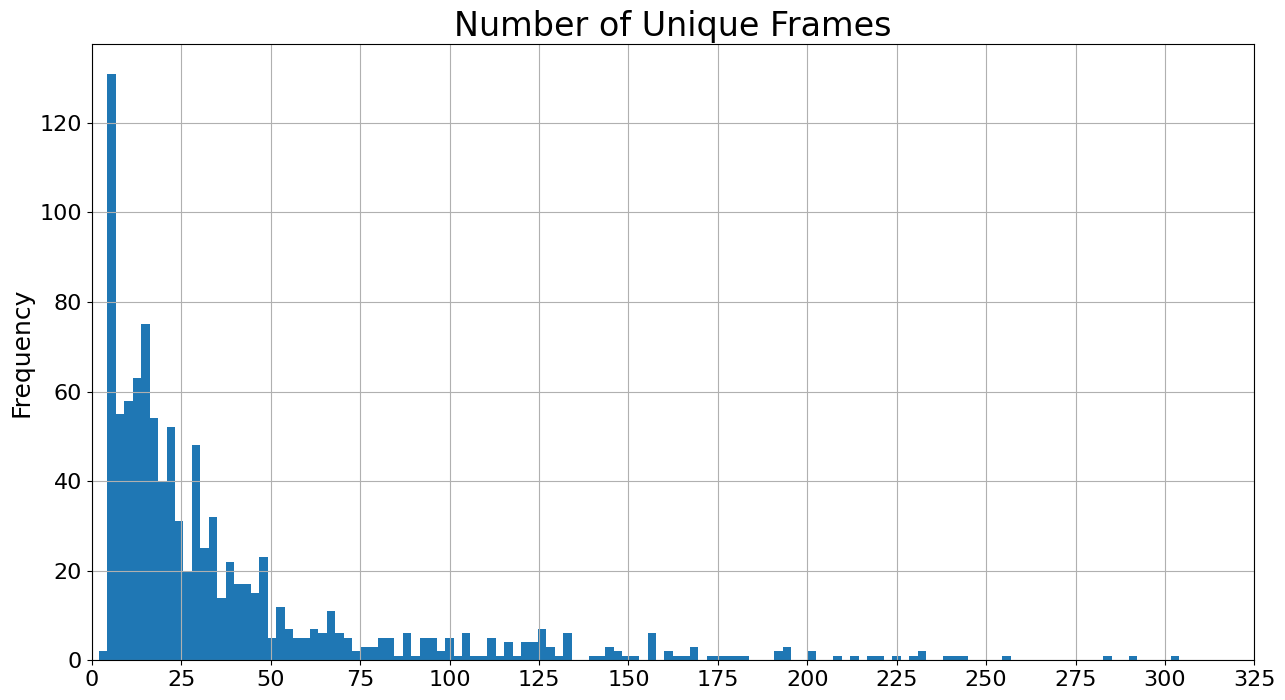

In [10]:
# Number of unique frames in each video
display(pd.Series(N_UNIQUE_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_UNIQUE_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Unique Frames', size=24)
pd.Series(N_UNIQUE_FRAMES).plot(kind='hist', bins=128)
plt.grid()
xlim = math.ceil(plt.xlim()[1])
plt.xlim(0, xlim)
plt.xticks(np.arange(0, xlim+25, 25))
plt.show() 

,N_MISSING_FRAMES
count,1000.0
mean,0.0
std,0.0
min,0.0
1%,0.0
5%,0.0
25%,0.0
50%,0.0
75%,0.0
95%,0.0


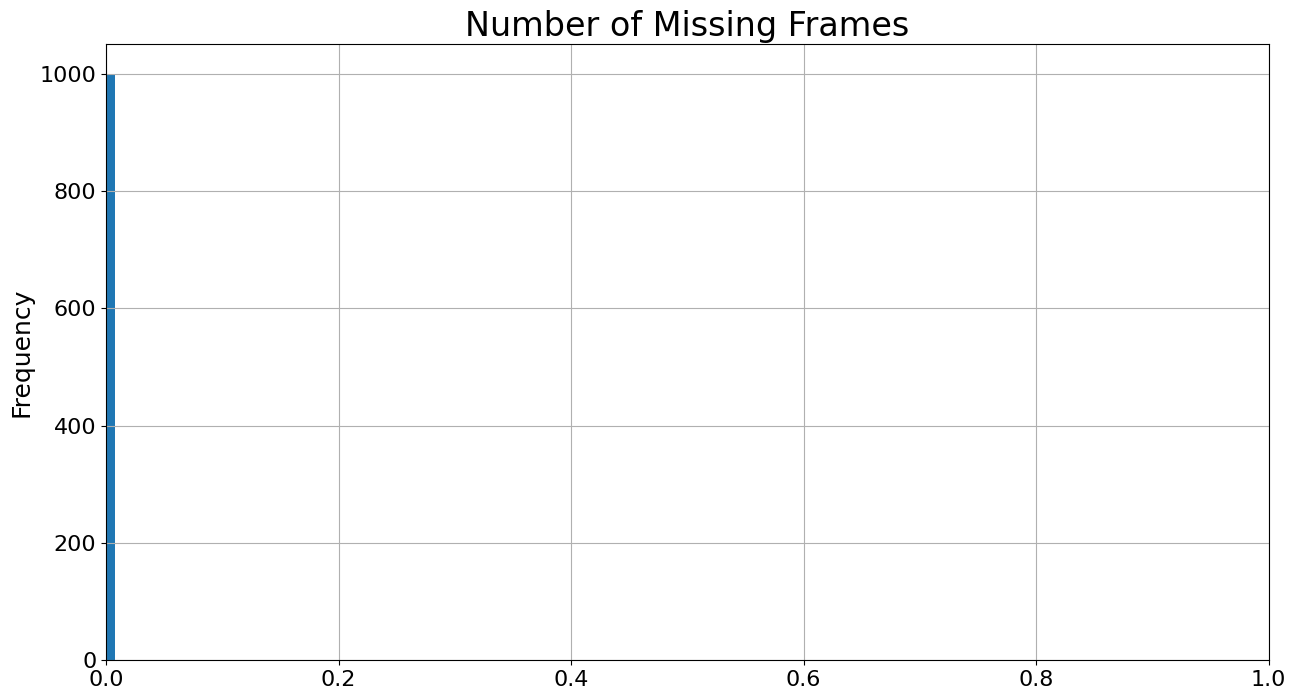

In [11]:
# Number of missing frames, consecutive frames with missing intermediate frame, i.e. 1,2,4,5 but 3 is missing
display(pd.Series(N_MISSING_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_MISSING_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Missing Frames', size=24)
pd.Series(N_MISSING_FRAMES).plot(kind='hist', bins=128)
plt.grid()
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

,MAX_FRAME
count,1000.000000
mean,67.844000
std,59.563138
min,2.000000
1%,12.000000
5%,21.950000
25%,33.000000
50%,43.000000
75%,64.000000
95%,202.050000


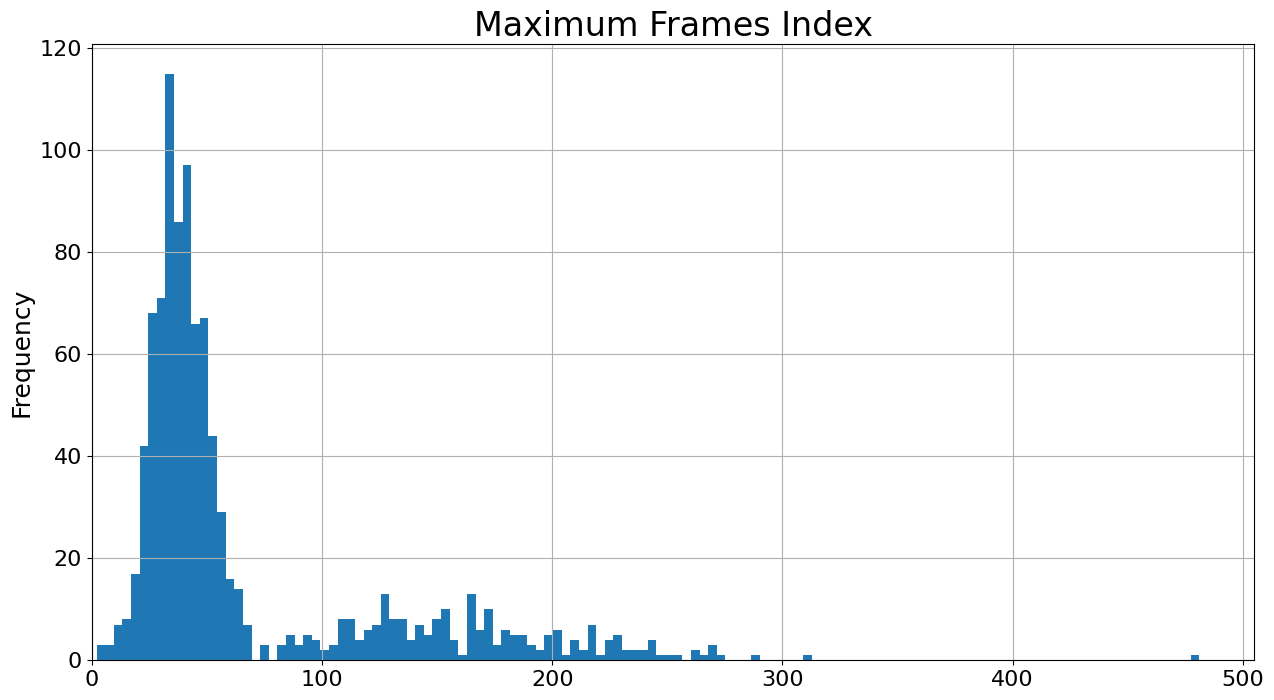

In [12]:
# Maximum frame number
display(pd.Series(MAX_FRAME).describe(percentiles=PERCENTILES).to_frame('MAX_FRAME'))

plt.figure(figsize=(15,8))
plt.title('Maximum Frames Index', size=24)
pd.Series(MAX_FRAME).plot(kind='hist', bins=128)
plt.grid() 
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

# Landmark Indices for Lips, Hands, and Pose

In [13]:
USE_TYPES = ['left_hand', 'pose', 'right_hand']
START_IDX = 468
LIPS_IDXS0 = np.array([
        61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
        291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
        78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
        95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    ])
# Landmark indices in original data
LEFT_HAND_IDXS0 = np.arange(468,489)
RIGHT_HAND_IDXS0 = np.arange(522,543)
LEFT_POSE_IDXS0 = np.array([502, 504, 506, 508, 510])
RIGHT_POSE_IDXS0 = np.array([503, 505, 507, 509, 511])
LANDMARK_IDXS_LEFT_DOMINANT0 = np.concatenate((LIPS_IDXS0, LEFT_HAND_IDXS0, LEFT_POSE_IDXS0))
LANDMARK_IDXS_RIGHT_DOMINANT0 = np.concatenate((LIPS_IDXS0, RIGHT_HAND_IDXS0, RIGHT_POSE_IDXS0))
HAND_IDXS0 = np.concatenate((LEFT_HAND_IDXS0, RIGHT_HAND_IDXS0), axis=0)
N_COLS = LANDMARK_IDXS_LEFT_DOMINANT0.size
# Landmark indices in processed data
LIPS_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LIPS_IDXS0)).squeeze()
LEFT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_HAND_IDXS0)).squeeze()
RIGHT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, RIGHT_HAND_IDXS0)).squeeze()
HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, HAND_IDXS0)).squeeze()
POSE_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_POSE_IDXS0)).squeeze()

print(f'# HAND_IDXS: {len(HAND_IDXS)}, N_COLS: {N_COLS}')

# HAND_IDXS: 21, N_COLS: 66


In [14]:
LIPS_START = 0
LEFT_HAND_START = LIPS_IDXS.size
RIGHT_HAND_START = LEFT_HAND_START + LEFT_HAND_IDXS.size
POSE_START = RIGHT_HAND_START + RIGHT_HAND_IDXS.size

print(f'LIPS_START: {LIPS_START}, LEFT_HAND_START: {LEFT_HAND_START}, RIGHT_HAND_START: {RIGHT_HAND_START}, POSE_START: {POSE_START}') 

LIPS_START: 0, LEFT_HAND_START: 40, RIGHT_HAND_START: 61, POSE_START: 61


# Process Data Tensorflow

In [15]:
ROWS_PER_FRAME = 543  # number of landmarks per frame

def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, len(data_columns))
    return data.astype(np.float32) 

In [16]:
# Removed strict input_signature to support Mixed Precision (Float16)
class PreprocessLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(PreprocessLayer, self).__init__() 
        self.lips_idxs = LIPS_IDXS
        self.left_hand_idxs = LEFT_HAND_IDXS
        self.pose_idxs = POSE_IDXS
        self.landmark_idxs_left = LANDMARK_IDXS_LEFT_DOMINANT0
        self.landmark_idxs_right = LANDMARK_IDXS_RIGHT_DOMINANT0
        
    def pad_edge(self, t, repeats, side):
        if side == 'LEFT':
            return tf.concat((tf.repeat(t[:1], repeats=repeats, axis=0), t), axis=0)
        elif side == 'RIGHT':
            return tf.concat((t, tf.repeat(t[-1:], repeats=repeats, axis=0)), axis=0)
    
    @tf.function
    def call(self, data0):
        # CAST TO FLOAT32: Ensure numeric stability for Normalization
        # Even if input is float16 (from Mixed Precision), we normalize in float32
        data0 = tf.cast(data0, tf.float32)

        # Filter dominant hand 
        left_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0.0, 1.0))
        right_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0.0, 1.0))
        left_dominant = left_hand_sum >= right_hand_sum
        
        # Filter frames where the dominant hand is present
        if left_dominant:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0.0, 1.0), axis=[1, 2]
            )
            # Select relevant landmarks (Lips + Left Hand + Pose)
            data = tf.gather(data0, self.landmark_idxs_left, axis=1)
        else:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0.0, 1.0), axis=[1, 2]
            )
            # Select relevant landmarks (Lips + Right Hand + Pose)
            data = tf.gather(data0, self.landmark_idxs_right, axis=1)
            # Mirror X coordinate for right-handers to make them look left-handed
            data = tf.concat([
                -1.0 * tf.expand_dims(data[:, :, 0], axis=-1), # Flip X
                tf.expand_dims(data[:, :, 1], axis=-1),        # Keep Y
                tf.expand_dims(data[:, :, 2], axis=-1)         # Keep Z
            ], axis=-1)
            
        # Get indices of valid frames
        non_empty_frames_idxs = tf.where(frames_hands_non_nan_sum > 0)
        non_empty_frames_idxs = tf.squeeze(non_empty_frames_idxs, axis=1)
        
        # Filter the data to only keep valid frames
        data = tf.gather(data, non_empty_frames_idxs, axis=0)

        # Grandmaster Normalization (Anchor to Lips/Nose)
        # We calculate the mean of the lips to use as the center (0,0,0)
        lips = data[:, :40, :] 
        
        # Calculate robust mean excluding NaNs
        lips_mean = tf.math.reduce_mean(tf.where(tf.math.is_nan(lips), 0.0, lips), axis=1, keepdims=True)
        lips_std = tf.math.reduce_std(tf.where(tf.math.is_nan(data), 0.0, data), axis=[1,2], keepdims=True) + 1e-6
        
        # Normalize: Center on lips, scale by global std
        data = (data - lips_mean) / lips_std
        
        # Fill NaNs with 0.0 after normalization
        data = tf.where(tf.math.is_nan(data), 0.0, data)

        # Resizing / Interpolation to INPUT_SIZE (128)
        N_FRAMES = tf.shape(data)[0]
        
        if N_FRAMES < INPUT_SIZE:
            # Pad with zeros at the end
            non_empty_frames_idxs = tf.pad(
                tf.cast(non_empty_frames_idxs, tf.float32), 
                [[0, INPUT_SIZE - N_FRAMES]], 
                constant_values=-1
            )
            data = tf.pad(data, [[0, INPUT_SIZE - N_FRAMES], [0,0], [0,0]], constant_values=0)
            
        else:
            # Downsample using Nearest Neighbor / Interpolation
            data_flat = tf.reshape(data, [1, N_FRAMES, -1, 1])
            data_resized = tf.image.resize(
                data_flat, 
                [INPUT_SIZE, tf.shape(data_flat)[2]], 
                method=tf.image.ResizeMethod.BILINEAR
            )
            # Reshape back to (INPUT_SIZE, Points, Dims)
            data = tf.reshape(data_resized, [INPUT_SIZE, -1, N_DIMS])
            
            # For indices, we take a linear spacing
            non_empty_frames_idxs = tf.linspace(0.0, tf.cast(N_FRAMES, tf.float32), INPUT_SIZE)

        # Motion Features (Lag1 & Lag2) 
        # Velocity (dX): x[t] - x[t-1]
        dx = data[1:, :, :] - data[:-1, :, :]
        dx = tf.concat([tf.zeros_like(data[:1, :, :]), dx], axis=0) # Pad start
        
        # Acceleration (ddX): dx[t] - dx[t-1]
        ddx = dx[1:, :, :] - dx[:-1, :, :]
        ddx = tf.concat([tf.zeros_like(dx[:1, :, :]), ddx], axis=0) # Pad start
        
        # Concatenate features: [X, Y, Z, dX, dY, dZ, ddX, ddY, ddZ]
        data = tf.concat([data, dx, ddx], axis=-1)
        
        # Flatten points and features for the dense input layer
        data = tf.reshape(data, (INPUT_SIZE, -1))
        
        return data, non_empty_frames_idxs

preprocess_layer = PreprocessLayer()

In [17]:
"""
    face: 0:468
    left_hand: 468:489
    pose: 489:522
    right_hand: 522:544
        
"""
def get_data(file_path):
    # Load Raw Data
    data = load_relevant_data_subset(file_path)
    # Process Data Using Tensorflow
    data = preprocess_layer(data)
    
    return data 

In [18]:
# Memory Optimized: Split Metadata FIRST to avoid "Copy Spike" OOM

def preprocess_data():
    # Infer Feature Shape
    print("Determining feature shape...")
    dummy_path = train['file_path'].values[0]
    dummy_data, _ = get_data(dummy_path)
    N_COLS_FINAL = dummy_data.shape[1]
    print(f"Features per frame: {N_COLS_FINAL}")

    # Split Metadata first
    print("Splitting metadata...")
    splitter = GroupShuffleSplit(test_size=0.10, n_splits=2, random_state=SEED)
    PARTICIPANT_IDS = train['participant_id'].values
    train_idxs, val_idxs = next(splitter.split(train, train['sign_ord'], groups=PARTICIPANT_IDS))
    
    # Create DataFrames for Train and Val
    df_train = train.iloc[train_idxs]
    df_val = train.iloc[val_idxs]
    
    print(f"Train Samples: {len(df_train)}")
    print(f"Val Samples: {len(df_val)}")

    # Global Variable Setup
    global X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN
    global X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL, validation_data

    # Process Training data
    print(f"Allocating X_train (approx {len(df_train)*INPUT_SIZE*N_COLS_FINAL*2 / 1e9:.2f} GB)...")
    
    # Allocate Train Arrays
    X_train = np.zeros([len(df_train), INPUT_SIZE, N_COLS_FINAL], dtype=np.float16)
    y_train = np.zeros([len(df_train)], dtype=np.int32)
    NON_EMPTY_FRAME_IDXS_TRAIN = np.full([len(df_train), INPUT_SIZE], -1, dtype=np.float16)
    
    print("Filling X_train...")
    # Iterate over Train Metadata only
    for i, (file_path, sign_ord) in enumerate(tqdm(df_train[['file_path', 'sign_ord']].values)):
        if i % 5000 == 0: gc.collect()
        
        data, non_empty_frame_idxs = get_data(file_path)
        
        X_train[i] = data.numpy().astype(np.float16)
        y_train[i] = sign_ord
        NON_EMPTY_FRAME_IDXS_TRAIN[i] = non_empty_frame_idxs.numpy().astype(np.float16)
        
        if np.isnan(data).sum() > 0:
            X_train[i] = np.nan_to_num(X_train[i])

    # Process Validation Data (If enabled)
    if USE_VAL:
        print("Processing Validation Data...")
        X_val = np.zeros([len(df_val), INPUT_SIZE, N_COLS_FINAL], dtype=np.float16)
        y_val = np.zeros([len(df_val)], dtype=np.int32)
        NON_EMPTY_FRAME_IDXS_VAL = np.full([len(df_val), INPUT_SIZE], -1, dtype=np.float16)
        
        for i, (file_path, sign_ord) in enumerate(tqdm(df_val[['file_path', 'sign_ord']].values)):
            data, non_empty_frame_idxs = get_data(file_path)
            
            X_val[i] = data.numpy().astype(np.float16)
            y_val[i] = sign_ord
            NON_EMPTY_FRAME_IDXS_VAL[i] = non_empty_frame_idxs.numpy().astype(np.float16)

        # Create Validation Tuple
        y_val_oh = tf.one_hot(y_val, NUM_CLASSES)
        validation_data = ({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, y_val_oh)
    else:
        validation_data = None

    return N_COLS_FINAL

# Execute
if PREPROCESS_DATA:
    N_COLS_FINAL = preprocess_data()

Determining feature shape...


I0000 00:00:1771832024.134717      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771832024.140773      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Features per frame: 594
Splitting metadata...
Train Samples: 80229
Val Samples: 14248
Allocating X_train (approx 12.20 GB)...
Filling X_train...


  0%|          | 0/80229 [00:00<?, ?it/s]

Processing Validation Data...


  0%|          | 0/14248 [00:00<?, ?it/s]

In [19]:
# Data Verification: Checks the in-memory arrays

# Verify N_COLS_FINAL is set
if 'N_COLS_FINAL' not in locals():
    # Fallback inference
    N_COLS_FINAL = X_train.shape[2]

print("-" * 30) 
print(f"Features per frame (N_COLS_FINAL): {N_COLS_FINAL}")
print(f"X_train shape: {X_train.shape}  | dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape}  | dtype: {y_train.dtype}")
print("-" * 30)

if USE_VAL:
    print(f"X_val shape:   {X_val.shape}    | dtype: {X_val.dtype}")

------------------------------
Features per frame (N_COLS_FINAL): 594
X_train shape: (80229, 128, 594)  | dtype: float16
y_train shape: (80229,)  | dtype: int32
------------------------------
X_val shape:   (14248, 128, 594)    | dtype: float16


In [20]:
# Class Count
display(pd.Series(y_train).value_counts().to_frame('Class Count').iloc[[0,1,2,3,4, -5,-4,-3,-2,-1]]) 

,Class Count
135,358
136,352
60,351
194,351
67,348
170,277
249,267
56,266
21,263
231,255


  0%|          | 0/128 [00:00<?, ?it/s]

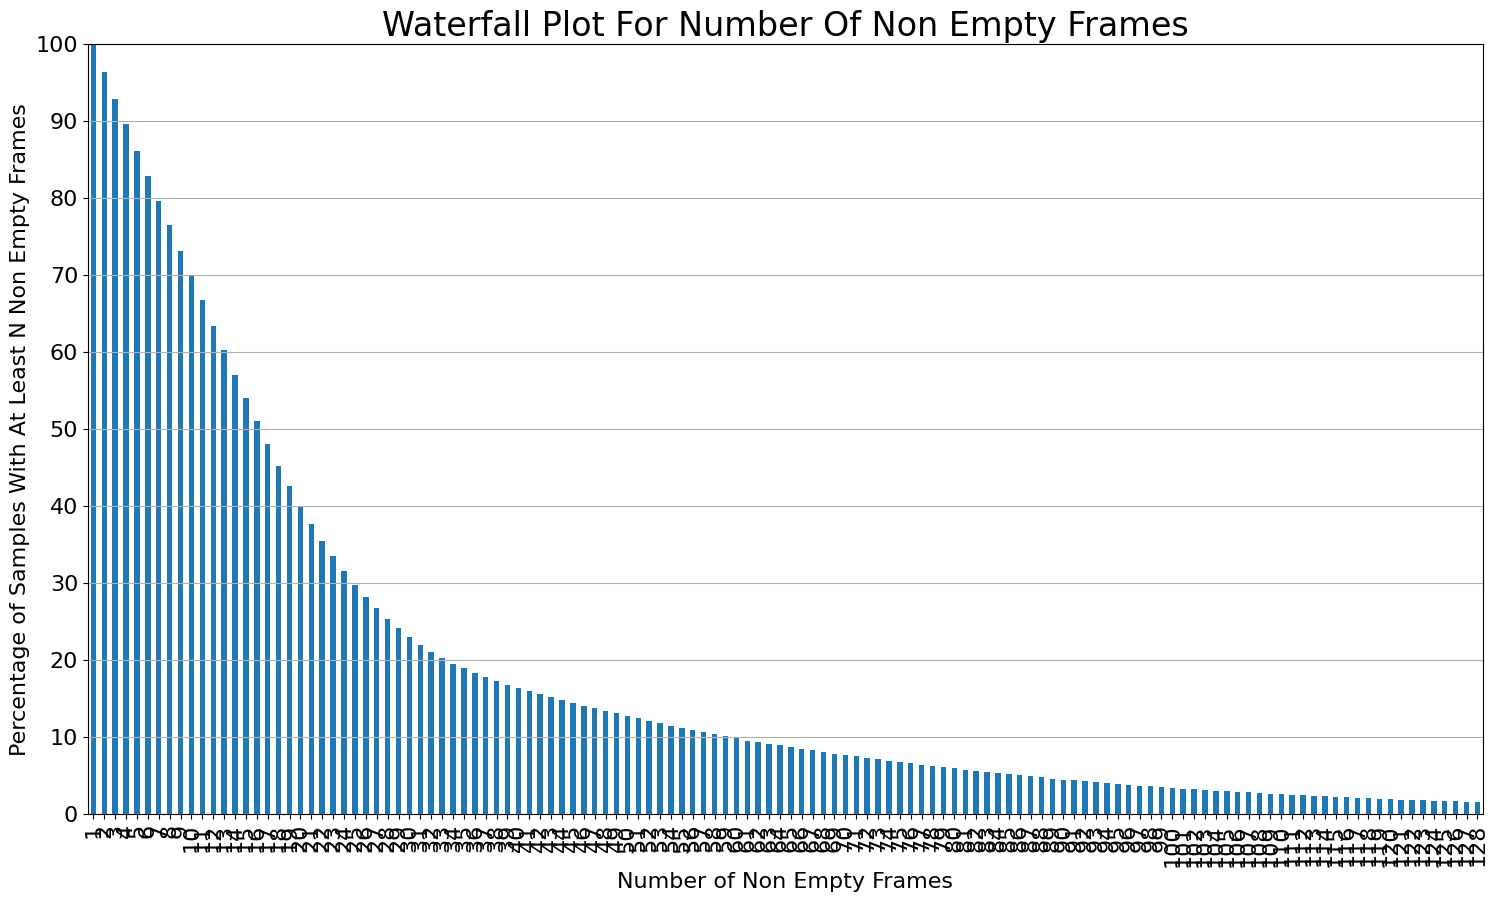

In [21]:
# Vast majority of samples fits has less than 32 non empty frames
N_EMPTY_FRAMES = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum(axis=1) 
N_EMPTY_FRAMES_WATERFALL = []
for n in tqdm(range(1,INPUT_SIZE+1)):
    N_EMPTY_FRAMES_WATERFALL.append(sum(N_EMPTY_FRAMES >= n) / len(NON_EMPTY_FRAME_IDXS_TRAIN) * 100)

plt.figure(figsize=(18,10))
plt.title('Waterfall Plot For Number Of Non Empty Frames')
pd.Series(N_EMPTY_FRAMES_WATERFALL).plot(kind='bar')
plt.grid(axis='y')
plt.xticks(np.arange(INPUT_SIZE), np.arange(1, INPUT_SIZE+1))
plt.xlabel('Number of Non Empty Frames', size=16)
plt.yticks(np.arange(0, 100+10, 10))
plt.ylim(0, 100)
plt.ylabel('Percentage of Samples With At Least N Non Empty Frames', size=16)
plt.show() 

# Samples

In [22]:
# Features: Standard Batching + MixUp + Feature Masking + Low FPS Simulation

def get_train_batch_all_signs(X, y, NON_EMPTY_FRAME_IDXS, batch_size=32, mixup_alpha=0.2):
    """
    Yields batches of 'batch_size' with robust On-the-Fly Augmentation.
    Includes 'Low FPS' simulation to teach the model to handle laggy video.
    """
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    while True:
        # Shuffle indices at the start of every epoch
        np.random.shuffle(indices)
        
        # Iterate through the dataset in chunks
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            
            # Skip incomplete last batch if it's too small (avoids stability issues)
            if end_idx - start_idx < 4: 
                continue
                
            batch_idxs = indices[start_idx:end_idx]
            current_batch_size = len(batch_idxs)
            
            # Shape: (Batch, 128, Features)
            X_batch = X[batch_idxs].astype(np.float32) # Cast to float32 for MixUp math
            y_batch = tf.one_hot(y[batch_idxs], NUM_CLASSES).numpy()
            non_empty_frame_idxs_batch = NON_EMPTY_FRAME_IDXS[batch_idxs]

            # Augmentations (On-the-fly)
            for b in range(current_batch_size):
                
                # Feature Masking (Dropout on inputs)
                # Randomly zero out 20% of the features to force robustness
                if np.random.rand() < 0.2:
                    mask_indices = np.random.choice(N_COLS_FINAL, int(N_COLS_FINAL*0.2), replace=False)
                    X_batch[b, :, mask_indices] = 0.0

                # Time Masking (Drop contiguous frames)
                # Simulates packet loss / dropped connection
                if np.random.rand() < 0.3:
                    len_mask = np.random.randint(5, 15)
                    start_mask = np.random.randint(0, INPUT_SIZE - len_mask)
                    X_batch[b, start_mask:start_mask+len_mask, :] = 0.0
                    non_empty_frame_idxs_batch[b, start_mask:start_mask+len_mask] = -1
                
                # Low FPS Simulation (Random Frame Skipping)
                # Drops every 2nd or 3rd frame to simulate 15fps/10fps webcam input
                if np.random.rand() < 0.3:
                    step = np.random.randint(2, 4) # Keep every 2nd or 3rd frame
                    # Create indices [0, 2, 4...]
                    frame_indices = np.arange(0, INPUT_SIZE, step)
                    
                    # Gather kept frames
                    kept_frames = X_batch[b, frame_indices, :]
                    kept_masks = non_empty_frame_idxs_batch[b, frame_indices]
                    
                    # Zero out the whole slot
                    X_batch[b] = 0.0
                    non_empty_frame_idxs_batch[b] = -1
                    
                    # Place kept frames at the start (compressing the sequence)
                    # This teaches the model that "fast" sequences are valid
                    valid_len = len(kept_frames)
                    X_batch[b, :valid_len, :] = kept_frames
                    non_empty_frame_idxs_batch[b, :valid_len] = kept_masks

            # 3. MixUp (Blend 2 samples)
            if mixup_alpha > 0 and np.random.rand() < 0.5:
                lam = np.random.beta(mixup_alpha, mixup_alpha)
                # Permute within the current batch
                perm_indices = np.random.permutation(current_batch_size)
                
                X_batch = lam * X_batch + (1 - lam) * X_batch[perm_indices]
                y_batch = lam * y_batch + (1 - lam) * y_batch[perm_indices]
                
                # For masks, take the dominant one (lambda > 0.5)
                if lam < 0.5:
                    non_empty_frame_idxs_batch = non_empty_frame_idxs_batch[perm_indices]
            
            yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch

In [23]:
dummy_dataset = get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN)
X_batch, y_batch = next(dummy_dataset)

for k, v in X_batch.items():
    print(f'{k} shape: {v.shape}, dtype: {v.dtype}')

# Batch shape/dtype
print(f'y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}')
# Verify each batch contains each sign exactly N times
display(pd.Series(np.argmax(y_batch, axis=1)).value_counts().to_frame('Counts')) 

frames shape: (32, 128, 594), dtype: float32
non_empty_frame_idxs shape: (32, 128), dtype: float16
y_batch shape: (32, 250), dtype: float32


,Counts
151,2
241,2
16,2
229,1
162,1
225,1
86,1
234,1
19,1
91,1


# Model Config

In [24]:
# Config
embed_dim = 192
num_heads = 4
ff_dim = embed_dim * 2
dropout_rate = 0.2

# Efficient Channel Attention (ECA)
class EcaLayer(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv1D(1, kernel_size=kernel_size, padding='same', use_bias=False)

    def call(self, x):
        attn = tf.reduce_mean(x, axis=1, keepdims=True)
        attn = tf.transpose(attn, (0, 2, 1))
        attn = self.conv(attn)
        attn = tf.transpose(attn, (0, 2, 1))
        attn = tf.math.sigmoid(attn)
        return x * attn

# Conv1D Block
class Conv1DBlock(tf.keras.layers.Layer):
    def __init__(self, dim, kernel_size=11, drop_rate=0.2, expand=4):
        super().__init__()
        self.conv = tf.keras.layers.DepthwiseConv1D(kernel_size, padding='same', use_bias=False)
        self.bn = tf.keras.layers.BatchNormalization()
        self.act = tf.keras.layers.Activation('swish') # Compatible activation
        self.se = EcaLayer(kernel_size=5)
        self.project = tf.keras.layers.Dense(dim, use_bias=False)
        self.drop = tf.keras.layers.Dropout(drop_rate)
        
    def call(self, x, training=None): # Make training optional
        skip = x
        x = self.conv(x)
        x = self.bn(x, training=training)
        x = self.act(x)
        x = self.se(x)
        x = self.project(x)
        if training:
            x = self.drop(x)
        return x + skip

# Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="gelu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    # Set training=None by default
    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output) 

class LearnablePositionalEmbedding(tf.keras.layers.Layer):
    """
    Adds a learnable vector to each frame position so the Transformer 
    knows 'where' it is in the sequence.
    """
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.pos_embedding = tf.keras.layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        # x shape: (Batch, Time, Features)
        max_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=max_len, delta=1)
        return x + self.pos_embedding(positions)

In [25]:
# Hybrid CNN-Transformer
# Added MaskingLayer
# Inserted LearnablePositionalEmbedding

class MaskingLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(MaskingLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        frames, non_empty_frame_idxs = inputs
        mask = tf.math.not_equal(non_empty_frame_idxs, -1)
        mask = tf.cast(mask, dtype=frames.dtype)
        mask_expanded = tf.expand_dims(mask, -1)
        return frames * mask_expanded

def get_model():
    # Input Shapes
    frames = tf.keras.layers.Input([INPUT_SIZE, N_COLS_FINAL], dtype=tf.float16, name='frames')
    non_empty_frame_idxs = tf.keras.layers.Input([INPUT_SIZE], dtype=tf.float16, name='non_empty_frame_idxs')
    
    # Apply Masking
    x = MaskingLayer(name='input_masking')([frames, non_empty_frame_idxs])
    
    # Stem
    x = tf.keras.layers.Dense(embed_dim, use_bias=False, name='stem_conv')(x)
    x = tf.keras.layers.BatchNormalization(momentum=0.95, name='stem_bn')(x)
    
    # Backbone
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    
    x = LearnablePositionalEmbedding(INPUT_SIZE, embed_dim)(x)
    
    # Transformer
    x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.2)(x)
    
    # CNNs
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    x = Conv1DBlock(embed_dim, kernel_size=17, drop_rate=0.2)(x)
    
    # Transformer
    x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.2)(x)
    
    #Head
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.8)(x) 
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='classifier')(x)
    
    # Model
    model = tf.keras.models.Model(inputs=[frames, non_empty_frame_idxs], outputs=outputs)
    
    # Optimizer (Native Weight Decay)
    optimizer = tf.optimizers.AdamW(learning_rate=LR_MAX, weight_decay=WD_RATIO)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc'),
    ]
    
    model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
    
    return model

tf.keras.backend.clear_session()
model = get_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 128, 594)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ non_empty_frame_id… │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_masking       │ (None, 128, 594)  │          0 │ frames[0][0],     │
│ (MaskingLayer)      │                   │            │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Dense)   │ (None, 128, 192)  │    114,048 │ input_masking[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 192)  │        768 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block        │ (None, 128, 192)  │     40,901 │ stem_bn[0][0]     │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block_1      │ (None, 128, 192)  │     40,901 │ conv1d_block[0][… │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block_2      │ (None, 128, 192)  │     40,901 │ conv1d_block_1[0… │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 128, 192)  │     24,576 │ conv1d_block_2[0… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 128, 192)  │    741,120 │ learnable_positi… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block_3      │ (None, 128, 192)  │     40,901 │ transformer_bloc… │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block_4      │ (None, 128, 192)  │     40,901 │ conv1d_block_3[0… │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_block_5      │ (None, 128, 192)  │     40,901 │ conv1d_block_4[0… │
│ (Conv1DBlock)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 128, 192)  │    741,120 │ conv1d_block_5[0… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 192)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 250)       │     48,250 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,915,288 (7.31 MB)

 Trainable params: 1,912,600 (7.30 MB)

 Non-trainable params: 2,688 (10.50 KB)

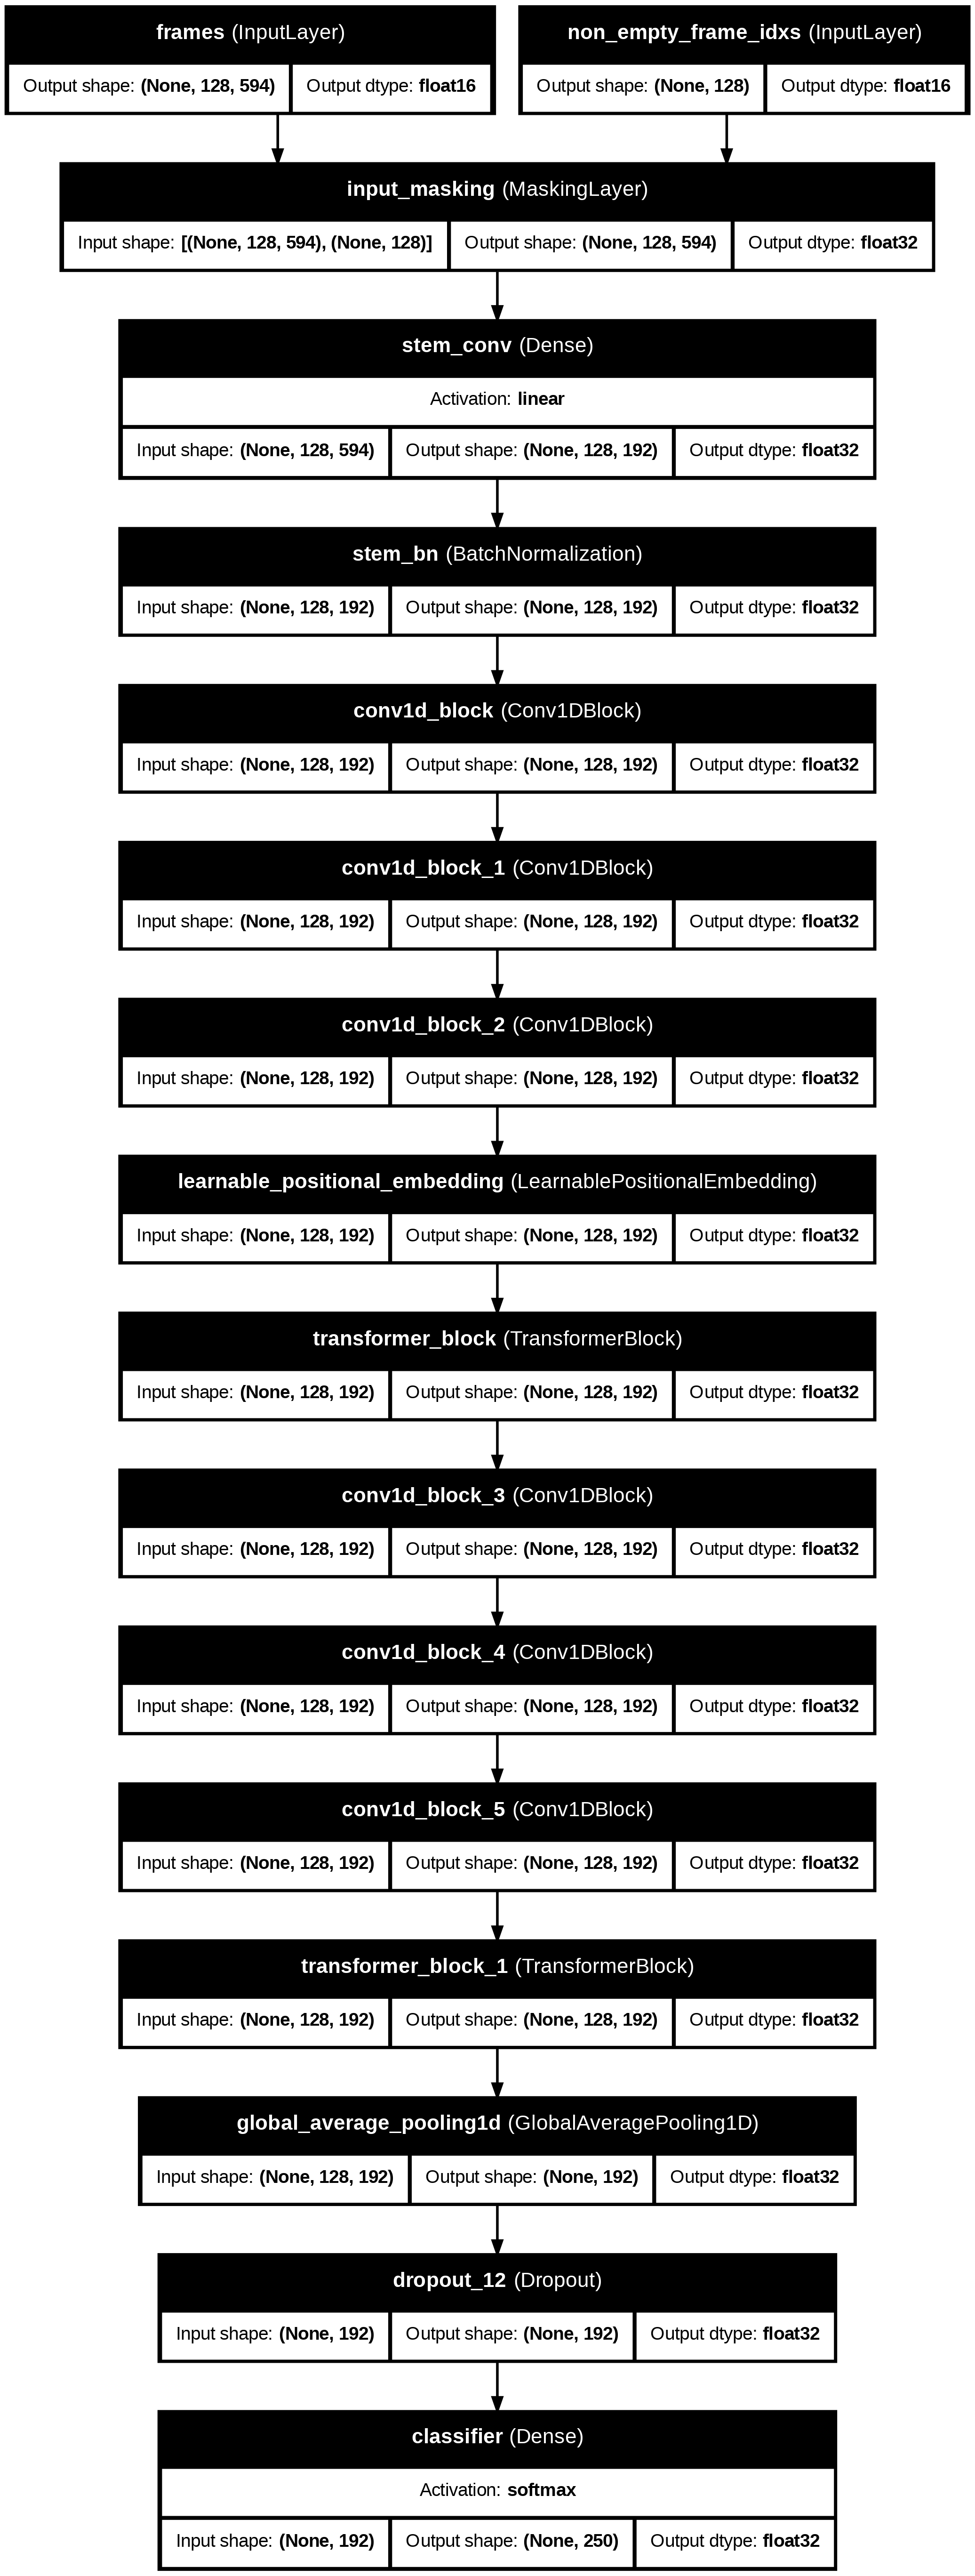

In [26]:
tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True, show_layer_activations=True) 

# No NaN Predictions

In [27]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    y_pred = model.predict_on_batch(X_batch).flatten()
    print(f'# NaN Values In Prediction: {np.isnan(y_pred).sum()}') 

# Weight Iitialization

In [28]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    plt.figure(figsize=(12,5))
    plt.title(f'Softmax Output Initialized Model | µ={y_pred.mean():.3f}, σ={y_pred.std():.3f}', pad=25)
    pd.Series(y_pred).plot(kind='hist', bins=128, label='Class Probability')
    plt.xlim(0, max(y_pred) * 1.1)
    plt.vlines([1 / NUM_CLASSES], 0, plt.ylim()[1], color='red', label=f'Random Guessing Baseline 1/NUM_CLASSES={1 / NUM_CLASSES:.3f}')
    plt.grid()
    plt.legend()
    plt.show() 

# Learning Rate Scheduler

In [29]:
# Calculate total steps
STEPS_PER_EPOCH = N_SAMPLES // BATCH_SIZE
TOTAL_STEPS = N_EPOCHS * STEPS_PER_EPOCH

def generate_one_cycle_step_wise(lr_max, total_steps, warmup_prop=0.3):
    lr_schedule = []
    warmup_steps = int(total_steps * warmup_prop)
    cooldown_steps = total_steps - warmup_steps
    
    initial_lr = lr_max / 25.0
    final_lr = lr_max / 10000.0
    
    for step in range(total_steps):
        if step < warmup_steps:
            lr = initial_lr + (lr_max - initial_lr) * (step / warmup_steps)
        else:
            progress = (step - warmup_steps) / cooldown_steps
            lr = final_lr + (lr_max - final_lr) * (0.5 * (1 + math.cos(math.pi * progress)))
        lr_schedule.append(lr)
    return lr_schedule

# Generate high-resolution schedule
LR_SCHEDULE_STEPS = generate_one_cycle_step_wise(LR_MAX, TOTAL_STEPS, warmup_prop=0.3)

# Custom Callback to update every BATCH
class StepLearningRateScheduler(tf.keras.callbacks.Callback):
    def __init__(self, schedule):
        super(StepLearningRateScheduler, self).__init__()
        self.schedule = schedule

    def on_train_batch_begin(self, batch, logs=None):
        # Calculate global step
        global_step = self.model.optimizer.iterations.numpy()
        if global_step < len(self.schedule):
            lr = self.schedule[global_step]
            self.model.optimizer.learning_rate.assign(lr)

lr_callback = StepLearningRateScheduler(LR_SCHEDULE_STEPS) 

# Weight Decay Callback

In [30]:
# Custom callback to update weight decay with learning rate
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=WD_RATIO):
        self.step_counter = 0
        self.wd_ratio = wd_ratio
    
    def on_epoch_begin(self, epoch, logs=None):
        model.optimizer.weight_decay = model.optimizer.learning_rate * self.wd_ratio
        print(f'learning rate: {model.optimizer.learning_rate.numpy():.2e}, weight decay: {model.optimizer.weight_decay.numpy():.2e}') 

# Training

In [31]:
if USE_VAL:
    # Verify val dataset covers all signs
    print(f'# Unique Signs in Validation Set: {pd.Series(y_val).nunique()}')
    # Value Counts
    display(pd.Series(y_val).value_counts().to_frame('Count').iloc[[1,2,3,-3,-2,-1]]) 

# Unique Signs in Validation Set: 250


,Count
38,67
235,66
172,66
106,43
170,35
249,32


# Sanity Check

In [32]:
# Sanity Check
if TRAIN_MODEL and USE_VAL:
    _ = model.evaluate(*validation_data, verbose=2) 

I0000 00:00:1771834155.426986     131 service.cc:152] XLA service 0x7d7edc08af60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771834155.430140     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771834155.430150     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771834156.220971     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771834161.300625     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


446/446 - 20s - 45ms/step - acc: 0.0035 - loss: 5.5758 - top_5_acc: 0.0176


In [33]:
if TRAIN_MODEL and USE_VAL:
    try:
        # validation_data is tuple (X, y)
        if isinstance(validation_data, tuple) or isinstance(validation_data, list):
            val_inputs, val_labels = validation_data
            if len(val_labels.shape) == 1:
                print('Converting validation labels to One-Hot')
                val_labels_oh = tf.one_hot(val_labels, NUM_CLASSES)
                validation_data = (val_inputs, val_labels_oh)
    except Exception as e:
        print(f'Warning: Could not auto-convert validation labels: {e}')

In [34]:
# Streams validation data in mini-batches to prevent GPU OOM at the end of the epoch

def get_val_batch(X, y, NON_EMPTY_FRAME_IDXS, batch_size=32):
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    while True:
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            
            batch_idxs = indices[start_idx:end_idx]
            
            # Fetch Data (Cast to float32 for model consistency)
            X_batch = X[batch_idxs].astype(np.float32)
            y_batch = tf.one_hot(y[batch_idxs], NUM_CLASSES).numpy()
            non_empty_frame_idxs_batch = NON_EMPTY_FRAME_IDXS[batch_idxs]
            
            yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch

In [35]:
# Config updates
N_EPOCHS = 200            
BATCH_SIZE = 32           
WARMUP_EPOCHS = 20        
INIT_LR = 1e-4
MAX_LR = 4e-4             
FINAL_LR = 1e-6

STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE

if USE_VAL:
    VAL_STEPS = len(X_val) // BATCH_SIZE
else:
    VAL_STEPS = None

TOTAL_STEPS = N_EPOCHS * STEPS_PER_EPOCH

print(f"   Epochs: {N_EPOCHS}")
print(f"   Train Steps: {STEPS_PER_EPOCH} | Val Steps: {VAL_STEPS}")

# Cosine Decay Schedule
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=MAX_LR,
    decay_steps=TOTAL_STEPS,
    alpha=FINAL_LR / MAX_LR
)

# Re-compile Model
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WD_RATIO)
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

metrics = [
    tf.keras.metrics.CategoricalAccuracy(name='acc'),
    tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc'),
]

model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

# Fit Model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20,          
    restore_best_weights=True, 
    verbose=1
)


if TRAIN_MODEL:
    history = model.fit(
            # Training Generator
            x=get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN, batch_size=BATCH_SIZE),
            steps_per_epoch=STEPS_PER_EPOCH,
            
            # Validation Generator (CRITICAL OOM FIX)
            validation_data=get_val_batch(X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL, batch_size=BATCH_SIZE) if USE_VAL else None,
            validation_steps=VAL_STEPS if USE_VAL else None,
            
            epochs=N_EPOCHS,
            callbacks=[early_stopping],
            verbose=VERBOSE,
        )
    
    model.save_weights('hybrid_model.weights.h5')
    
    # ── Save Training History to CSV ──────────────────────────────────────────────
    history_df = pd.DataFrame(history.history)
    history_df.index += 1          # epoch numbers start at 1
    history_df.index.name = 'epoch'
    history_df.to_csv('training_history.csv')
    print(f"Training history saved → training_history.csv  ({len(history_df)} epochs logged)")
    display(history_df.head())

   Epochs: 200
   Train Steps: 2507 | Val Steps: 445
Epoch 1/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 144s 44ms/step - acc: 0.0062 - loss: 5.7085 - top_5_acc: 0.0305 - val_acc: 0.0612 - val_loss: 4.7166 - val_top_5_acc: 0.2215
Epoch 2/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 122s 41ms/step - acc: 0.0441 - loss: 4.9364 - top_5_acc: 0.1653 - val_acc: 0.1769 - val_loss: 3.9759 - val_top_5_acc: 0.4892
Epoch 3/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - acc: 0.1079 - loss: 4.4555 - top_5_acc: 0.3393 - val_acc: 0.2801 - val_loss: 3.4971 - val_top_5_acc: 0.6147
Epoch 4/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 105s 42ms/step - acc: 0.1809 - loss: 4.1286 - top_5_acc: 0.4669 - val_acc: 0.3538 - val_loss: 3.1777 - val_top_5_acc: 0.7014
Epoch 5/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 103s 41ms/step - acc: 0.2390 - loss: 3.9110 - top_5_acc: 0.5465 - val_acc: 0.4114 - val_loss: 2.9356 - val_top_5_acc: 0.7537
Epoch 6/200
2507/2507 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - acc: 0.2917 - loss: 3.7179 - top_5_acc: 0.6023 

,acc,loss,top_5_acc,val_acc,val_loss,val_top_5_acc
epoch,,,,,,
1,0.011568,5.477617,0.051718,0.061166,4.716619,0.221489
2,0.056935,4.803035,0.208200,0.176896,3.975883,0.489185
3,0.125603,4.362920,0.376722,0.280126,3.497101,0.614677
4,0.194708,4.074399,0.488572,0.353756,3.177679,0.701393
5,0.254897,3.847584,0.564360,0.411438,2.935611,0.753658


In [36]:
#if USE_VAL:
    # val dataset predictions
    #y_val_pred = model.predict({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, verbose=2).argmax(axis=1)
    # Label
    #labels = [ORD2SIGN.get(i).replace(' ', '_') for i in range(NUM_CLASSES)] 

In [37]:
import gc
import ctypes
import pickle

# PHASE 1: SECURE THE TRAINING HISTORY
# We save this FIRST. If the kernel crashes during inference, 
# you can simply load this file in a new notebook to generate the training accuracy and loss plots.
if 'history' in globals():
    with open('history_backup.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print("Training history saved to 'history_backup.pkl'.") 

Training history saved to 'history_backup.pkl'.


In [38]:
# AGGRESSIVE MEMORY FLUSH 
# 1. Delete Training Data
if 'X_train' in globals():
    del X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN
    print("🧹 Python variables deleted.")

# 2. Force Garbage Collection
gc.collect()

# 3. Force Malloc Trim (The Secret Weapon)
# This forces the C-level memory allocator to release freed memory back to the OS.
try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
    print("📉 System memory explicitly trimmed.")
except Exception as e:
    print(f"⚠️ Could not trim malloc: {e}")

🧹 Python variables deleted.
📉 System memory explicitly trimmed.


In [39]:
# STREAMED INFERENCE (Low Memory)
if USE_VAL:
    print(f"Starting Streamed Inference on {len(X_val)} samples...")
    
    # Pre-allocate the result array (Int16 is tiny compared to Float32 probabilities)
    y_val_pred = np.zeros(len(X_val), dtype=np.int16)
    
    # Manual Batching Loop
    # We predict small chunks and immediately Argmax to save RAM
    chunk_size = 1000 # Process 1000 samples at a time (RAM safe)
    sub_batch_size = 32 # Feed GPU 32 at a time (VRAM safe)
    
    total_chunks = int(np.ceil(len(X_val) / chunk_size))
    
    for i in tqdm(range(total_chunks), desc="Streaming Predictions"):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(X_val))
        
        # 1. Select Slice
        batch_frames = X_val[start:end]
        batch_idxs = NON_EMPTY_FRAME_IDXS_VAL[start:end]
        
        # 2. Predict (Returns Probabilities)
        # Using a fresh predict call for each chunk prevents memory accumulation
        probs = model.predict(
            {'frames': batch_frames, 'non_empty_frame_idxs': batch_idxs}, 
            batch_size=sub_batch_size, 
            verbose=0
        )
        
        # 3. Argmax immediately (Compress 250 floats -> 1 int)
        y_val_pred[start:end] = probs.argmax(axis=1).astype(np.int16)
        
        # 4. Explicit Cleanup
        del probs, batch_frames, batch_idxs
        gc.collect()
    
    # Generate Labels for Report
    labels = [ORD2SIGN.get(i).replace(' ', '_') for i in range(NUM_CLASSES)]
    print("Inference Complete.") 

Starting Streamed Inference on 14248 samples...


Streaming Predictions:   0%|          | 0/15 [00:00<?, ?it/s]

Inference Complete.


# Landmark Attention Weights

In [40]:
#embedding_layer = None
#for layer in model.layers:
 #   if 'embedding' in layer.name:
  #      embedding_layer = layer
   #     break

#if embedding_layer is None:
 #   raise RuntimeError("Embedding layer not found in the model.")

#landmark_weights_var = getattr(embedding_layer, 'landmark_weights', None)

#if landmark_weights_var is None:
 #   raise RuntimeError("'landmark_weights' attribute not found in the embedding layer.")

# Convert to numpy and apply softmax for readable weights
#import scipy

#weights = scipy.special.softmax(landmark_weights_var.numpy())

 #Print weights
#landmarks = ['lips_embedding', 'left_hand_embedding', 'pose_embedding']

#for w, lm in zip(weights, landmarks):
 #   print(f'{lm} weight: {(w * 100):.1f}%') 

# Classification Report

In [41]:
def print_classification_report():
    # Classification report for all signs
    classification_report = sklearn.metrics.classification_report(
            y_val,
            y_val_pred,
            target_names=labels,
            output_dict=True,
        )
    # Round Data for better readability
    classification_report = pd.DataFrame(classification_report).T
    classification_report = classification_report.round(2)
    classification_report = classification_report.astype({
            'support': np.uint16,
        })
    # Add signs
    classification_report['sign'] = [e if e in SIGN2ORD else -1 for e in classification_report.index]
    classification_report['sign_ord'] = classification_report['sign'].apply(SIGN2ORD.get).fillna(-1).astype(np.int16)
    # Sort on F1-score
    classification_report = pd.concat((
        classification_report.head(NUM_CLASSES).sort_values('f1-score', ascending=False),
        classification_report.tail(3),
    ))

    pd.options.display.max_rows = 999
    display(classification_report)

In [42]:
if USE_VAL:
    print_classification_report() 

,precision,recall,f1-score,support,sign,sign_ord
food,1.00,1.00,1.00,57,food,87
brown,0.97,0.97,0.97,58,brown,31
gum,0.95,0.98,0.97,59,gum,103
uncle,0.98,0.95,0.97,60,uncle,228
nose,0.95,1.00,0.97,58,nose,155
please,0.97,0.97,0.97,60,please,173
shirt,0.96,0.96,0.96,54,shirt,195
for,0.95,0.96,0.96,57,for,88
drink,0.96,0.95,0.96,57,drink,63
shhh,0.92,1.00,0.96,60,shhh,194


# Report Analytics

## 1. Top-1 vs Top-5 Accuracy

Computing Top-1 and Top-5 accuracy...

────────────────────────────────────────
  Top-1 Accuracy : 0.7498  (74.98%)
  Top-5 Accuracy : 0.9289  (92.89%)
  Gap (Top5-Top1): 17.91 pp
────────────────────────────────────────



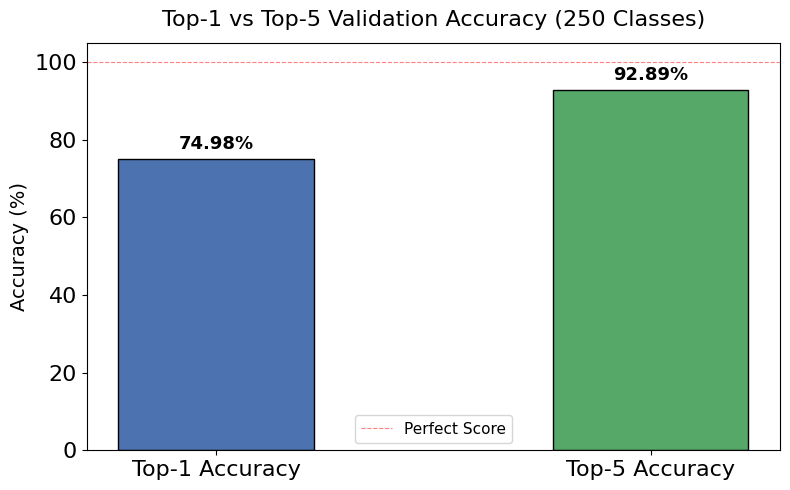

In [43]:
if USE_VAL:
    # ── Streamed Top-5 Inference ──────────────────────────────────────────────
    # Re-run prediction to collect full probability distributions for Top-5
    print('Computing Top-1 and Top-5 accuracy...')

    top1_correct  = 0
    top5_correct  = 0
    total_samples = len(X_val)
    chunk_size    = 1000
    sub_batch     = 32

    for i in range(int(np.ceil(total_samples / chunk_size))):
        start = i * chunk_size
        end   = min(start + chunk_size, total_samples)

        probs = model.predict(
            {'frames': X_val[start:end].astype(np.float32),
             'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL[start:end]},
            batch_size=sub_batch, verbose=0
        )  # (chunk, 250)

        true_labels   = y_val[start:end]
        top1_preds    = probs.argmax(axis=1)
        top5_preds    = np.argsort(probs, axis=1)[:, -5:]  # top-5 indices

        top1_correct += (top1_preds == true_labels).sum()
        top5_correct += np.array([true_labels[j] in top5_preds[j] for j in range(len(true_labels))]).sum()

        del probs
        import gc; gc.collect()

    top1_acc = top1_correct / total_samples
    top5_acc = top5_correct / total_samples

    print(f'\n{"─" * 40}')
    print(f'  Top-1 Accuracy : {top1_acc:.4f}  ({top1_acc*100:.2f}%)')
    print(f'  Top-5 Accuracy : {top5_acc:.4f}  ({top5_acc*100:.2f}%)')
    print(f'  Gap (Top5-Top1): {(top5_acc - top1_acc)*100:.2f} pp')
    print(f'{"─" * 40}\n')

    # ── Bar chart ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(['Top-1 Accuracy', 'Top-5 Accuracy'],
                  [top1_acc * 100, top5_acc * 100],
                  color=['#4C72B0', '#55A868'], width=0.45, edgecolor='black')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title('Top-1 vs Top-5 Validation Accuracy (250 Classes)', fontsize=16, pad=12)
    for bar, val in zip(bars, [top1_acc, top5_acc]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f'{val*100:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.axhline(100, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Perfect Score')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


## 2. Confusion Matrix – Top 20 Most Confused Sign Pairs

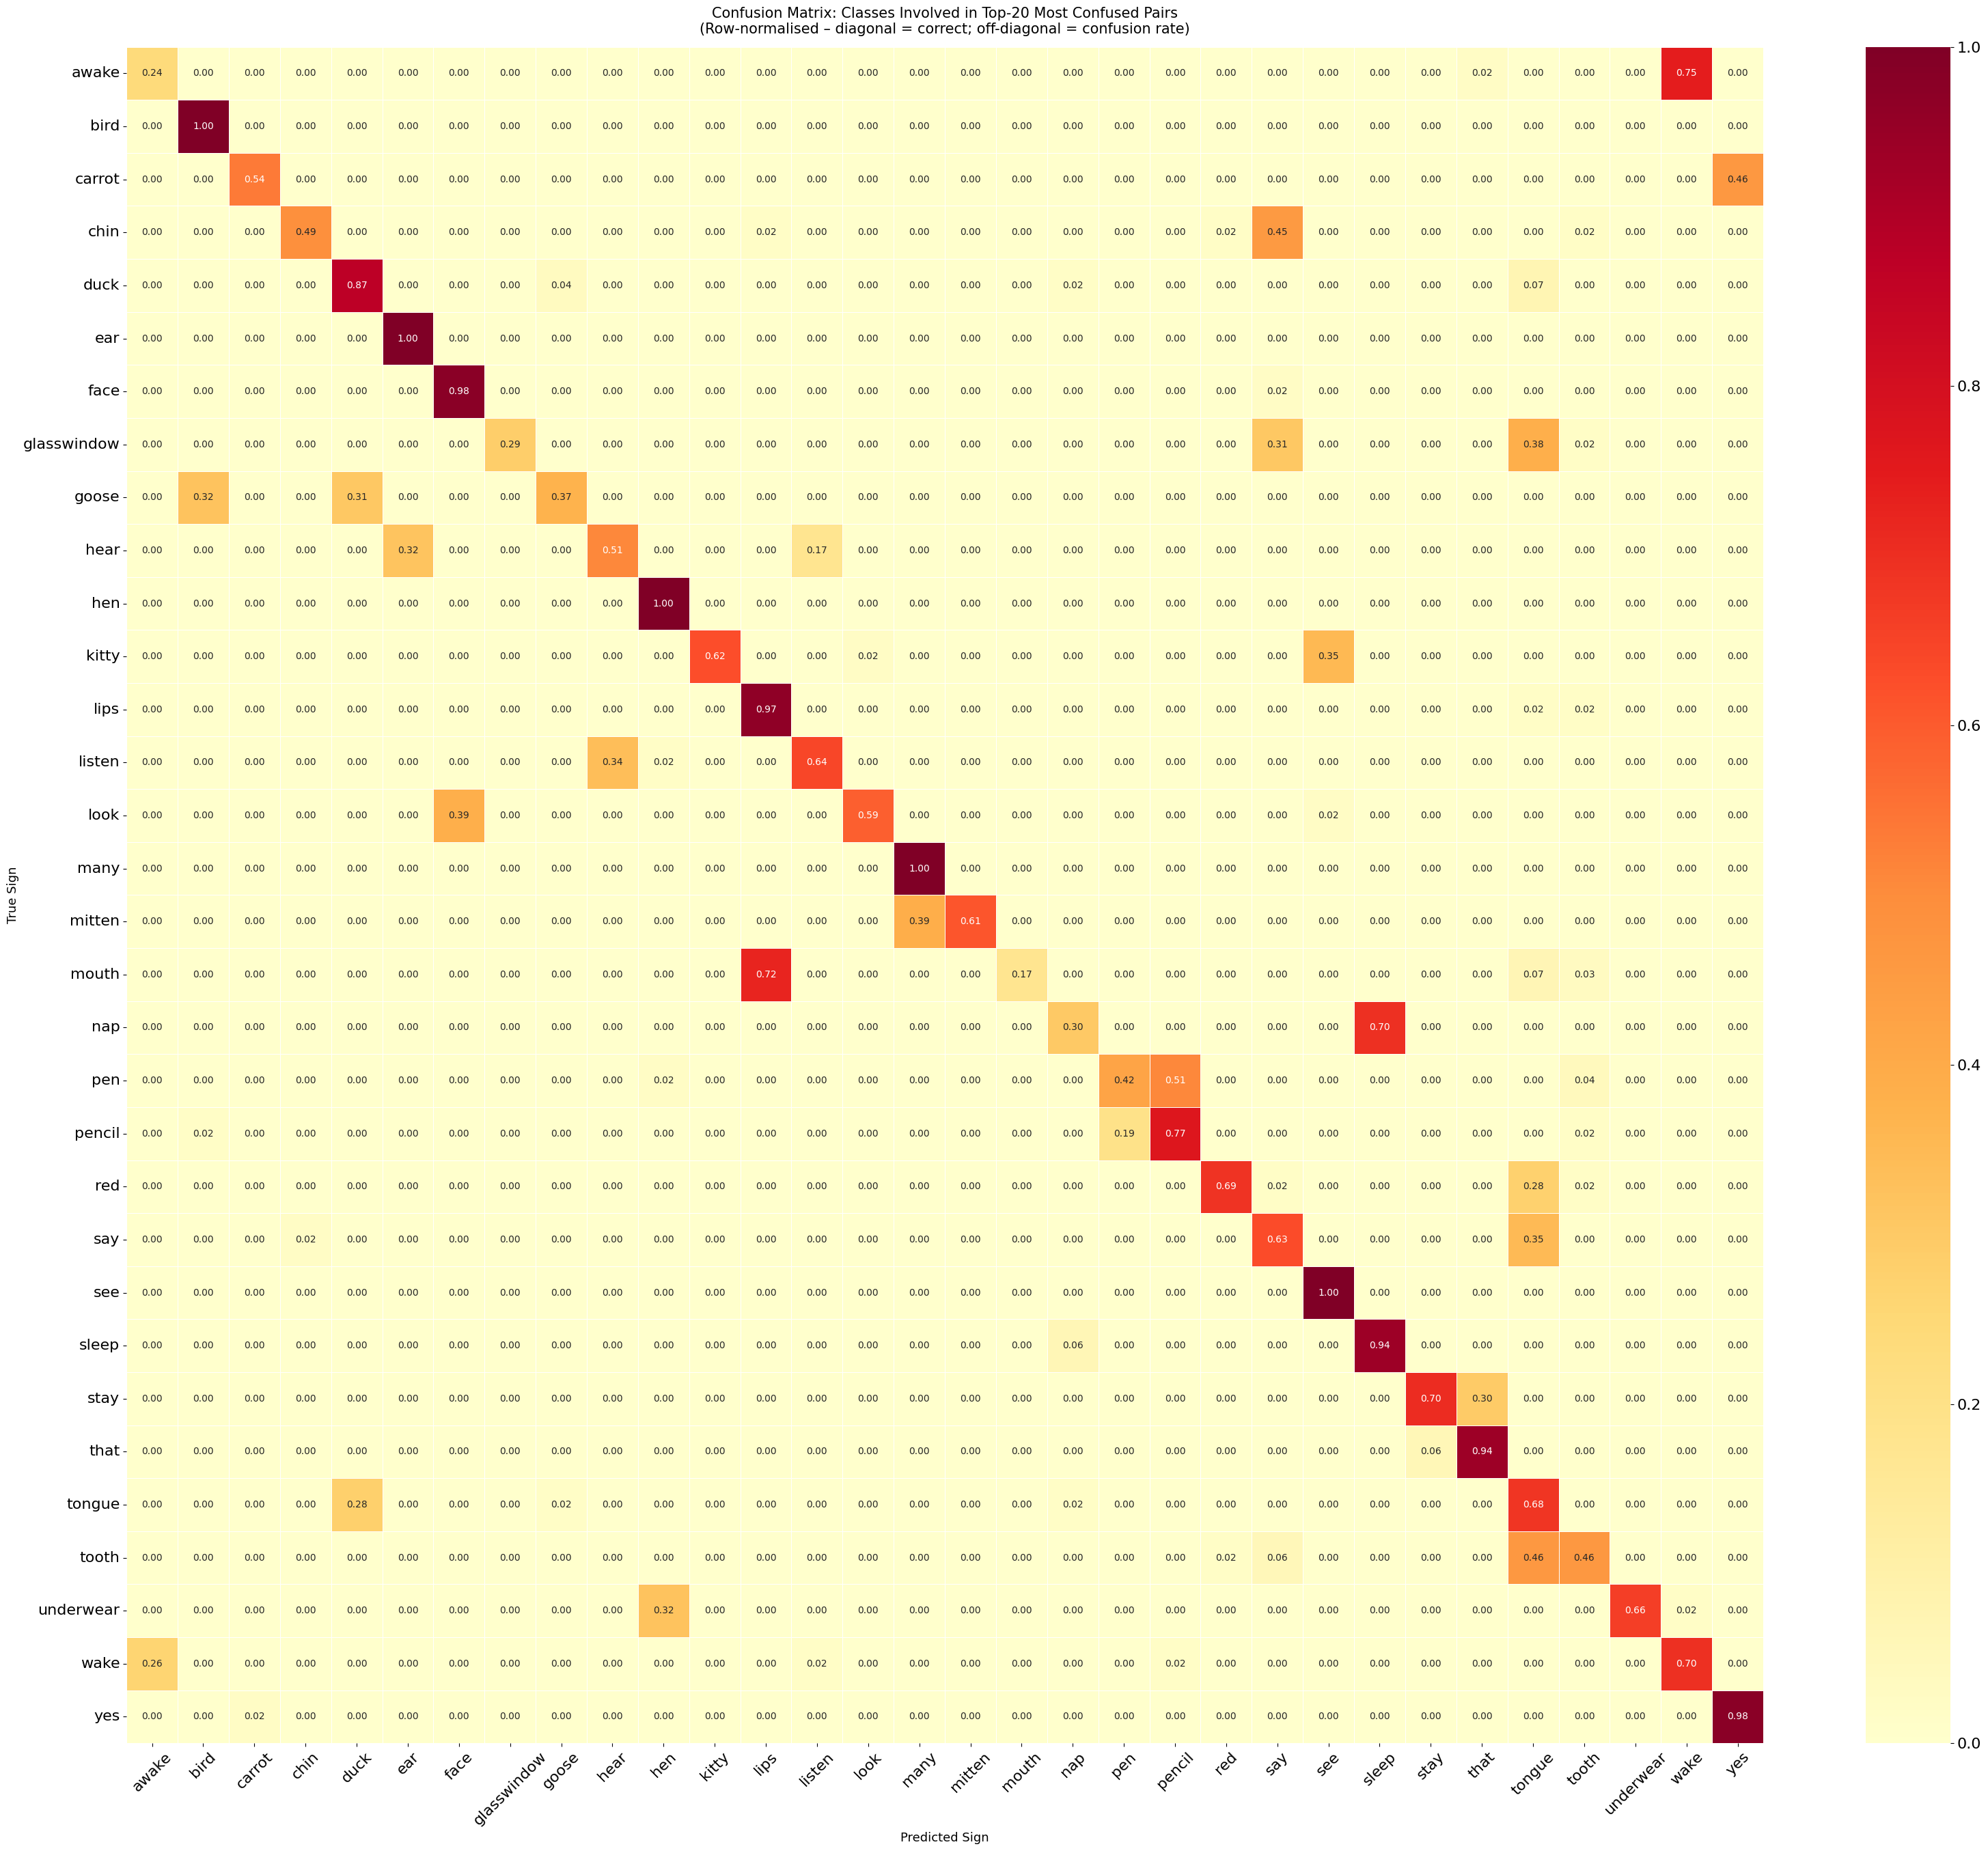


── Top 20 Most Confused Sign Pairs ─────────────────────────────
Rank   True Sign            Predicted As          Count
────────────────────────────────────────────────────────
1      mouth                lips                     42
2      awake                wake                     38
3      nap                  sleep                    37
4      chin                 say                      25
5      carrot               yes                      24
6      tooth                tongue                   24
7      pen                  pencil                   23
8      mitten               many                     23
9      hear                 ear                      20
10     glasswindow          tongue                   20
11     goose                bird                     19
12     underwear            hen                      19
13     goose                duck                     18
14     listen               hear                     18
15     look                 face     

In [44]:
if USE_VAL:
    from sklearn.metrics import confusion_matrix

    # y_val_pred already computed by the streamed inference cell above
    cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(NUM_CLASSES))  # (250, 250)

    # ── Extract off-diagonal (confused) pairs ─────────────────────────────────
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    # Flatten and find the top-20 confused (true_class, pred_class) pairs
    flat_indices  = np.argsort(cm_no_diag.ravel())[::-1][:20]
    top_pairs_rc  = np.unravel_index(flat_indices, cm_no_diag.shape)
    top_true_idxs = top_pairs_rc[0]
    top_pred_idxs = top_pairs_rc[1]

    # Unique classes involved in the top-20 confused pairs
    unique_classes = np.unique(np.concatenate([top_true_idxs, top_pred_idxs]))
    unique_labels  = [ORD2SIGN[i] for i in unique_classes]

    # Sub-matrix for those classes only
    sub_cm = cm[np.ix_(unique_classes, unique_classes)]

    # ── Plot heatmap ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(12, len(unique_classes)), max(10, len(unique_classes) * 0.85)))

    # Normalise each row so we see confusion rate (not raw counts)
    row_sums    = sub_cm.sum(axis=1, keepdims=True)
    sub_cm_norm = np.where(row_sums > 0, sub_cm / row_sums, 0.0)

    sns.heatmap(
        sub_cm_norm,
        annot=True, fmt='.2f',
        xticklabels=unique_labels,
        yticklabels=unique_labels,
        cmap='YlOrRd',
        linewidths=0.4,
        ax=ax
    )
    ax.set_title(
        'Confusion Matrix: Classes Involved in Top-20 Most Confused Pairs\n'
        '(Row-normalised – diagonal = correct; off-diagonal = confusion rate)',
        fontsize=15, pad=14
    )
    ax.set_xlabel('Predicted Sign', fontsize=13)
    ax.set_ylabel('True Sign',      fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.show()

    # ── Print top-20 confused pairs as a table ────────────────────────────────
    print('\n── Top 20 Most Confused Sign Pairs ─────────────────────────────')
    print(f'{"Rank":<6} {"True Sign":<20} {"Predicted As":<20} {"Count":>6}')
    print('─' * 56)
    for rank, (tr, pr) in enumerate(zip(top_true_idxs, top_pred_idxs), 1):
        print(f'{rank:<6} {ORD2SIGN[tr]:<20} {ORD2SIGN[pr]:<20} {cm_no_diag[tr, pr]:>6}')


## 3. Per-Class F1 Score – Best 5 & Worst 5 Signs

── Best 5 Signs (highest F1) ─────────────────────────────────


,sign,f1_score,support
0,food,1.000000,57
1,nose,0.974790,58
2,please,0.966667,60
3,gum,0.966667,59
4,uncle,0.966102,60



── Worst 5 Signs (lowest F1) ─────────────────────────────────


,sign,f1_score,support
0,give,0.210526,53
1,mouth,0.281690,60
2,awake,0.282353,57
3,go,0.289157,53
4,owie,0.329897,57


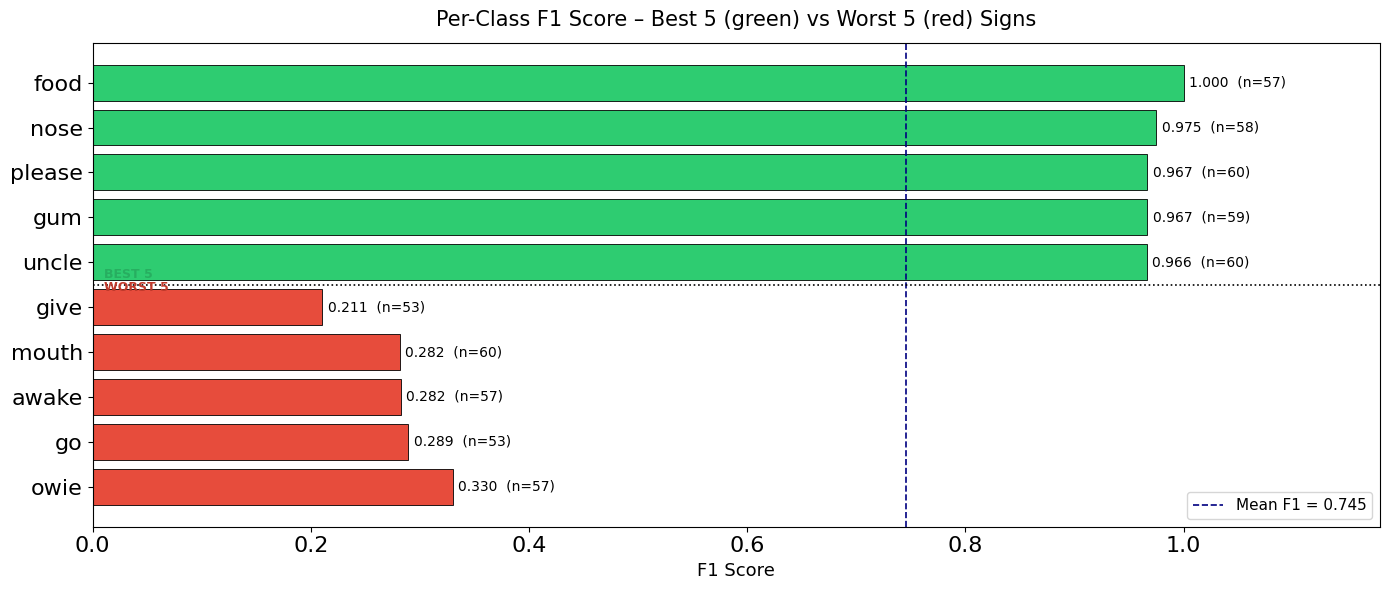


Overall Macro-F1   : 0.7451
Median Per-Class F1: 0.7665
Classes with F1 < 0.50: 19 / 250
Classes with F1 > 0.90: 35 / 250


In [45]:
if USE_VAL:
    from sklearn.metrics import f1_score

    # Per-class F1 (macro over each class individually)
    per_class_f1 = f1_score(y_val, y_val_pred, labels=np.arange(NUM_CLASSES),
                            average=None, zero_division=0)  # shape (250,)

    # Build a tidy DataFrame
    f1_df = pd.DataFrame({
        'sign'     : [ORD2SIGN[i] for i in range(NUM_CLASSES)],
        'f1_score' : per_class_f1,
        'support'  : [(y_val == i).sum() for i in range(NUM_CLASSES)],
    }).sort_values('f1_score', ascending=False).reset_index(drop=True)

    best5  = f1_df.head(5)
    worst5 = f1_df.tail(5).iloc[::-1]   # worst first

    print('── Best 5 Signs (highest F1) ─────────────────────────────────')
    display(best5[['sign', 'f1_score', 'support']].reset_index(drop=True))

    print('\n── Worst 5 Signs (lowest F1) ─────────────────────────────────')
    display(worst5[['sign', 'f1_score', 'support']].reset_index(drop=True))

    # ── Combined bar chart ────────────────────────────────────────────────────
    combined = pd.concat([best5, worst5], ignore_index=True)
    colors   = ['#2ecc71'] * 5 + ['#e74c3c'] * 5  # green / red

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(
        combined['sign'][::-1],
        combined['f1_score'][::-1],
        color=colors[::-1],
        edgecolor='black', linewidth=0.6
    )

    # Annotate bars with F1 value and support
    for bar, (_, row) in zip(bars, combined[::-1].iterrows()):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{row["f1_score"]:.3f}  (n={row["support"]})',
            va='center', ha='left', fontsize=10
        )

    ax.set_xlim(0, 1.18)
    ax.set_xlabel('F1 Score', fontsize=13)
    ax.set_title('Per-Class F1 Score – Best 5 (green) vs Worst 5 (red) Signs', fontsize=15, pad=12)
    ax.axvline(per_class_f1.mean(), color='navy', linestyle='--', linewidth=1.2,
               label=f'Mean F1 = {per_class_f1.mean():.3f}')
    ax.legend(fontsize=11)

    # Divider line between best / worst
    ax.axhline(4.5, color='black', linewidth=1.2, linestyle=':')
    ax.text(0.01, 4.65, 'BEST 5', fontsize=9, color='#27ae60', fontweight='bold')
    ax.text(0.01, 4.35, 'WORST 5', fontsize=9, color='#c0392b', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Overall summary ───────────────────────────────────────────────────────
    print(f'\nOverall Macro-F1   : {per_class_f1.mean():.4f}')
    print(f'Median Per-Class F1: {np.median(per_class_f1):.4f}')
    print(f'Classes with F1 < 0.50: {(per_class_f1 < 0.50).sum()} / {NUM_CLASSES}')
    print(f'Classes with F1 > 0.90: {(per_class_f1 > 0.90).sum()} / {NUM_CLASSES}')


# Training History

In [46]:
def plot_history_metric(metric, f_best=np.argmax, ylim=None, yscale=None, yticks=None):
    plt.figure(figsize=(20, 10))
    
    values = history.history[metric]
    N_EPOCHS = len(values)
    val = 'val' in ''.join(history.history.keys())
    # Epoch ticks
    if N_EPOCHS <= 20:
        x = np.arange(1, N_EPOCHS + 1)
    else:
        x = [1, 5] + [10 + 5 * idx for idx in range((N_EPOCHS - 10) // 5 + 1)]

    x_ticks = np.arange(1, N_EPOCHS+1)

    # Validation
    if val:
        val_values = history.history[f'val_{metric}']
        val_argmin = f_best(val_values)
        plt.plot(x_ticks, val_values, label=f'val')

    # summarize history for accuracy
    plt.plot(x_ticks, values, label=f'train')
    argmin = f_best(values)
    plt.scatter(argmin + 1, values[argmin], color='red', s=75, marker='o', label=f'train_best')
    if val:
        plt.scatter(val_argmin + 1, val_values[val_argmin], color='purple', s=75, marker='o', label=f'val_best')

    plt.title(f'Model {metric}', fontsize=24, pad=10)
    plt.ylabel(metric, fontsize=20, labelpad=10)

    if ylim:
        plt.ylim(ylim)

    if yscale is not None:
        plt.yscale(yscale)
        
    if yticks is not None:
        plt.yticks(yticks, fontsize=16)

    plt.xlabel('epoch', fontsize=20, labelpad=10)        
    plt.tick_params(axis='x', labelsize=8)
    plt.xticks(x, fontsize=16) # set tick step to 1 and let x axis start at 1
    plt.yticks(fontsize=16)
    
    plt.legend(prop={'size': 10})
    plt.grid()
    plt.show()

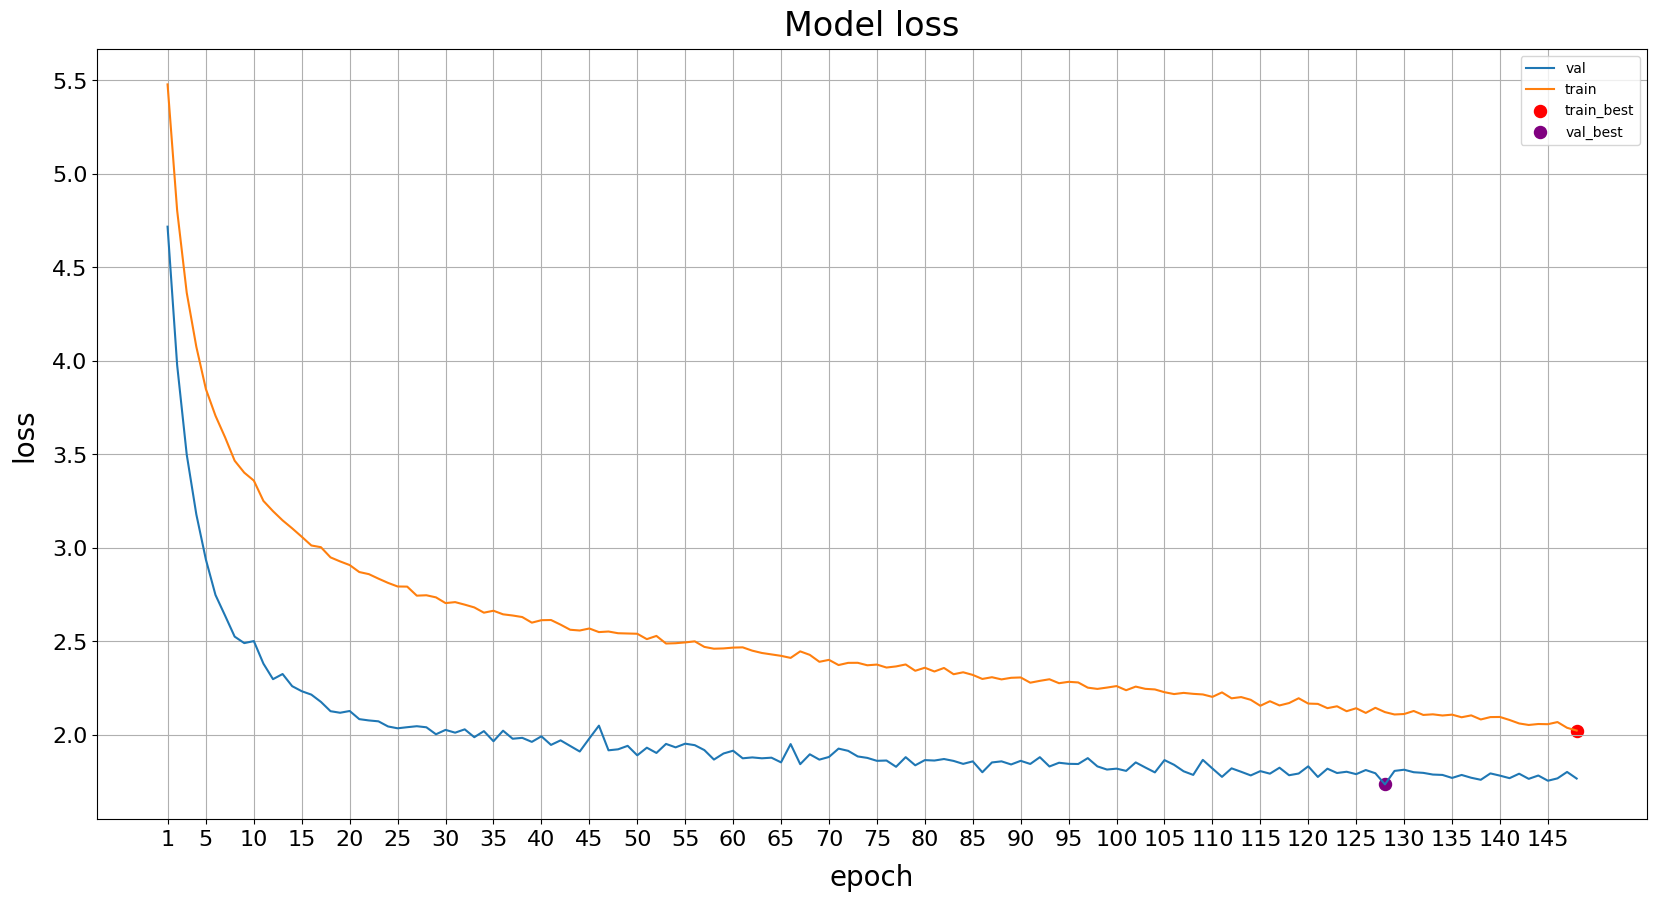

In [47]:
if TRAIN_MODEL:
    plot_history_metric('loss', f_best=np.argmin) 

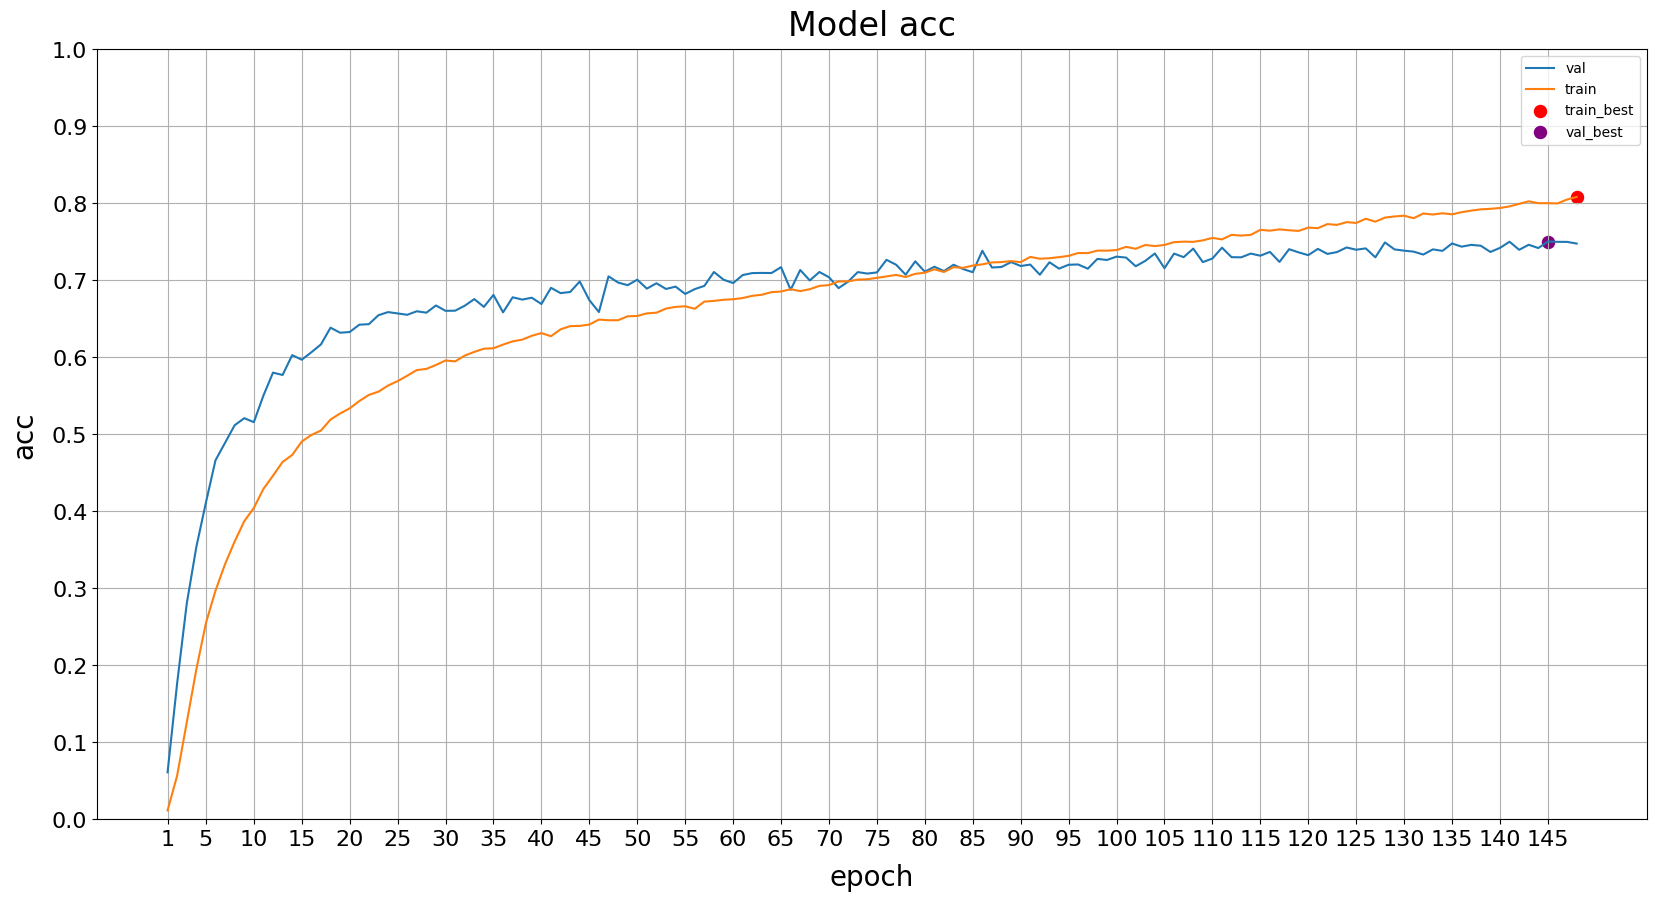

In [48]:
if TRAIN_MODEL:
    plot_history_metric('acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1)) 

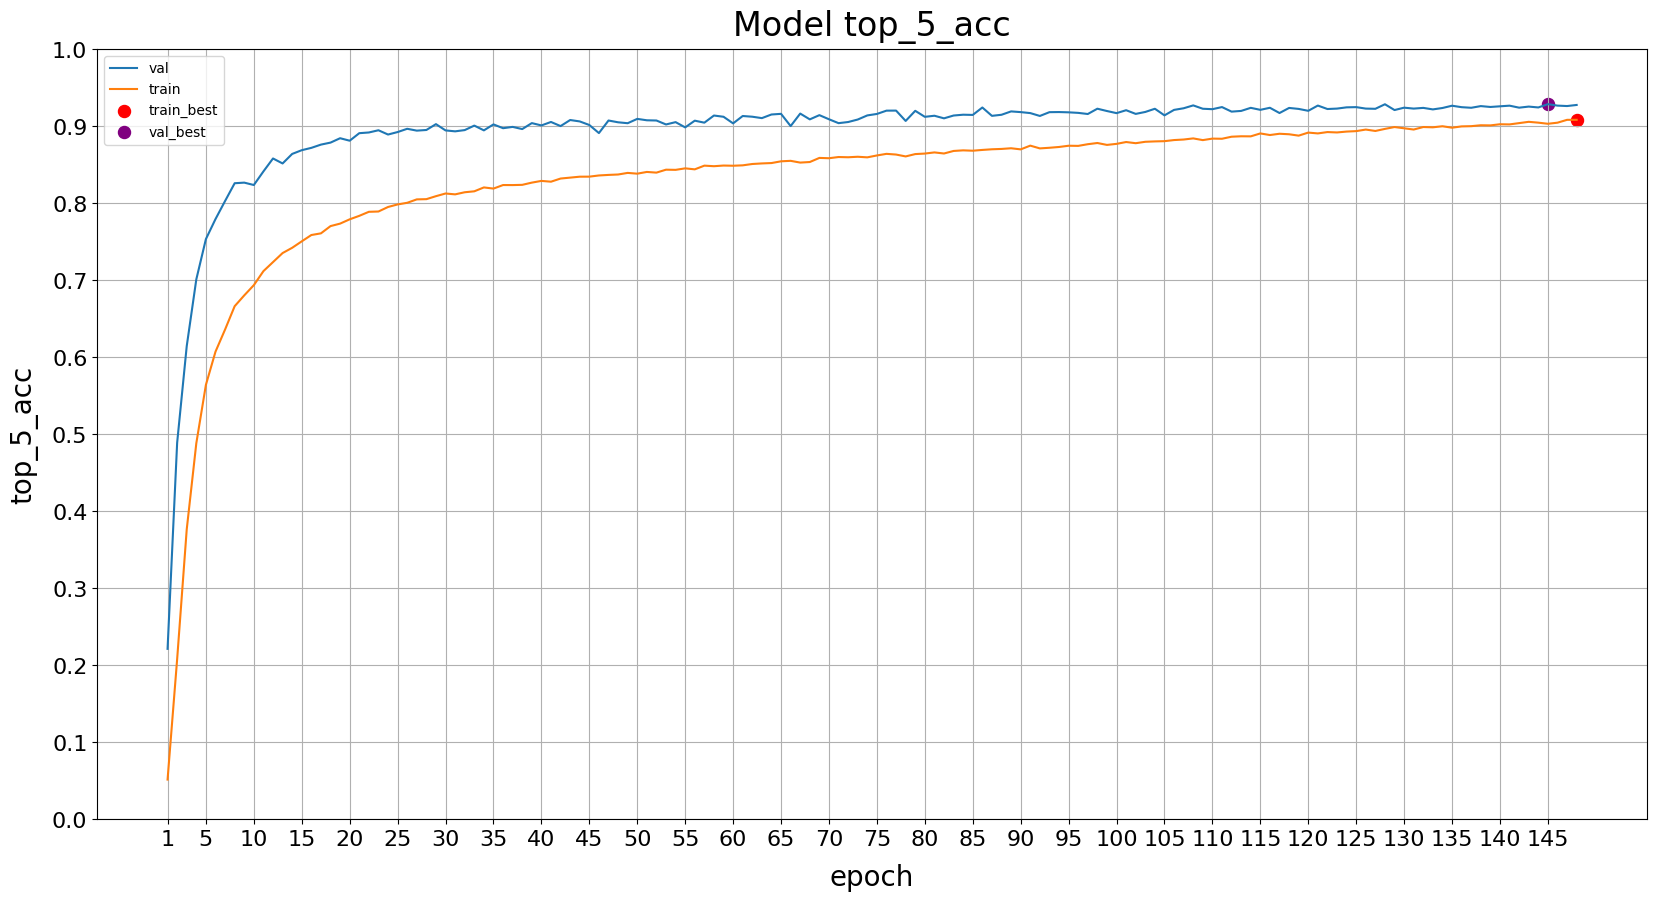

In [49]:
if TRAIN_MODEL:
    plot_history_metric('top_5_acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1))